# SQuAD v2 Pressure Ulcer QA Dataset Construction

**Module:** 7146COMP Advanced Topics in Deep Learning  
**Stage:** 1 — Dataset Construction  
**Date:** 2026-04-29

---

## Abstract

This notebook documents the complete pipeline for constructing a SQuAD v2-format question-answering dataset on pressure ulcer prevention and management. The dataset is intended for fine-tuning three transformer-based architectures — BERT, ClinicalBERT, and RoBERTa — under a SQuAD-style extractive QA framework. Three independent pipelines are executed, each using a different document chunk size (250, 300, and 400 tokens), to enable systematic investigation of the effect of context length on downstream model performance.

This stage covers only dataset construction. No model training is performed here.

---

## Section 1: Coursework Requirements

The table below maps each coursework requirement to the methodology adopted in this notebook and identifies the evidence produced.

| Coursework Requirement | How This Stage Satisfies It | Evidence |
|---|---|---|
| Dataset construction | Three-pipeline chunking → QA generation → filtering → SQuAD assembly | Code cells run end-to-end |
| 5,000–8,000 QA pairs per pipeline | 7,280 (chunk=250) / 6,105 (chunk=300) / 4,718 (chunk=400) | Final count table in Section 10 |
| Answerable + unanswerable questions | LLM prompt generates both; unanswerable flagged `is_impossible: true` | Per-pipeline answerable/unanswerable counts |
| SQuAD v2 formatting | `squad_formatter.py` produces exact SQuAD v2 JSON schema | `validate_squad_schema()` output |
| Markdown justifications | Every design decision has an academic Markdown cell | Visual inspection |
| Dataset quality justification | Diversity filtering stats, validation pass rates, distribution plots | Visualisation cells |
| Preparation for BERT training | 80/10/10 chunk-level split, no leakage, balanced topics | Split statistics table |
| Three independent chunk-size pipelines | Completely independent pipelines: 250/300/400 tokens | Three separate output directories |

---

## Section 2: Source Material Description

The quality and reliability of a fine-tuned clinical NLP model is directly constrained by the quality of its training data. In healthcare contexts, where inaccurate outputs may directly influence clinical decision-making, the use of unverified or unsourced materials poses an unacceptable risk to patient safety. Accordingly, this dataset is constructed exclusively from internationally recognised clinical guidelines, NHS-endorsed documentation, and validated educational materials, ensuring that all generated QA pairs are grounded in authoritative and traceable clinical knowledge.

Three source categories are used:

| Source ID | Category | Document Title | Year | Clinical Area |
|---|---|---|---|---|
| SRC_A01 | A — EPUAP 2025 Guideline | Device-Related Pressure Injuries | 2025 | Device-related pressure injuries |
| SRC_A02 | A — EPUAP 2025 Guideline | Etiology of Pressure Injuries | 2025 | Aetiology and pathophysiology |
| SRC_A03 | A — EPUAP 2025 Guideline | Heel Pressure Injuries | 2025 | Heel pressure injury management |
| SRC_A04 | A — EPUAP 2025 Guideline | Nutrition | 2025 | Nutritional assessment and support |
| SRC_A05 | A — EPUAP 2025 Guideline | Repositioning | 2025 | Repositioning and early mobilisation |
| SRC_A06 | A — EPUAP 2025 Guideline | Seating | 2025 | Seating and wheelchair positioning |
| SRC_A07 | A — EPUAP 2025 Guideline | Skin and Prevention | 2025 | Skin assessment and prevention |
| SRC_A08 | A — EPUAP 2025 Guideline | Support Surfaces | 2025 | Support surfaces and pressure redistribution |
| SRC_A09 | A — EPUAP 2024 | From Screening to Full Risk Assessment | 2024 | Risk assessment and screening |
| SRC_B01 | B — NHS Clinical Document | NICE CG179: Pressure Ulcers — Prevention and Management | 2024 | UK clinical practice guideline |
| SRC_B02 | B — NHS Clinical Document | NHS Stop the Pressure: Summary Recommendations | 2024 | UK pressure ulcer prevention policy |
| SRC_C01 | C — Educational Material | Braden Scale: Teaching Guide and Scoring Instructions | 2024 | Risk assessment — Braden Scale |
| SRC_C02 | C — Educational Material | Guidelines for Pressure Ulcer Risk Assessment: Adapted Waterlow Score | 2024 | Risk assessment — Waterlow Score |

All source documents are stored as plain text files in `sources/raw/` and tracked in `sources/metadata.json`. No unverified web content, blogs, or unsourced PDFs are used. All documents carry clear institutional authorship (EPUAP, NICE, NHS England).

> **Note on AI-generated content:** Question-answer pairs in this dataset are generated automatically using a local Ollama language model (`gemma3:12b`). All generated content is grounded in, and validated against, the source text passages. The use of automated generation is declared in accordance with academic integrity requirements.

---

## Section 3: Imports and Configuration

In [1]:
import sys
import json
import random
import importlib
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import ollama
from collections import Counter
import numpy as np

# Add project root to path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from pressure_ulcer_qa import config
from pressure_ulcer_qa.chunking import load_sources, run_chunking_pipeline, load_chunks
from pressure_ulcer_qa.qa_generation import run_qa_generation, load_raw_qa_pairs
from pressure_ulcer_qa.validation import run_validation, load_validated_pairs, assert_all_spans_valid
from pressure_ulcer_qa.diversity_filter import run_diversity_filter, load_filtered_pairs
from pressure_ulcer_qa.squad_formatter import run_squad_assembly, load_squad_json
from pressure_ulcer_qa.split import run_split

random.seed(config.RANDOM_SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Ollama model: {config.OLLAMA_MODEL}")
print(f"Chunk sizes: {list(config.CHUNK_CONFIGS.keys())}")
print(f"Diversity threshold: {config.DIVERSITY_THRESHOLD}")
print(f"Random seed: {config.RANDOM_SEED}")

Project root: C:\Users\MSC1\Desktop\AdvancedDL\pressure_ulcer_qa
Ollama model: gemma3:12b
Chunk sizes: [250, 300, 400]
Diversity threshold: 0.85
Random seed: 42


---

## Section 4: Load Source Documents

In [2]:
sources = load_sources()
print(f"\nLoaded {len(sources)} source documents:\n")
rows = []
for sid, (meta, text) in sources.items():
    rows.append({
        "Source ID": sid,
        "Category": meta.category,
        "Title": meta.title[:60] + "..." if len(meta.title) > 60 else meta.title,
        "Word Count": len(text.split()),
        "Char Count": len(text),
    })
pd.DataFrame(rows)


Loaded 13 source documents:



,Source ID,Category,Title,Word Count,Char Count
0,SRC_A01,A,EPUAP/NPIAP/PPPIA 2019 Prevention and Treatmen...,4685,33607
1,SRC_A02,A,EPUAP 2025 Clinical Practice Guideline: Etiolo...,2154,15627
2,SRC_A03,A,EPUAP 2025 Clinical Practice Guideline: Heel P...,5692,38969
3,SRC_A04,A,EPUAP 2025 Clinical Practice Guideline: Nutrit...,8066,60563
4,SRC_A05,A,EPUAP 2025 Clinical Practice Guideline: Reposi...,13836,101110
5,SRC_A06,A,EPUAP 2025 Clinical Practice Guideline: Seatin...,5622,41572
6,SRC_A07,A,EPUAP 2025 Clinical Practice Guideline: Skin A...,5881,41384
7,SRC_A08,A,EPUAP 2025 Clinical Practice Guideline: Suppor...,8345,58941
8,SRC_A09,A,EPUAP 2024 Guideline: From Screening to Full P...,8024,48826
9,SRC_B01,B,NICE CG179: Pressure ulcers: prevention and ma...,6952,50362


---

## Section 5: Document Chunking

### Methodology

BERT imposes a hard maximum input sequence length of 512 subword tokens, arising from its fixed positional embedding design (Devlin et al., 2019). Clinical guidelines such as the EPUAP/NPIAP/PPPIA document far exceed this limit and cannot be processed as single inputs without truncation, which risks discarding critical clinical context. Document chunking decomposes source texts into discrete, contextually coherent passages that fit within this constraint, enabling the model to process each passage as an independent SQuAD-style context.

Three chunk sizes — 250, 300, and 400 tokens — are evaluated to investigate the effect of context length on both dataset quality and downstream model performance. Shorter chunks are expected to produce more focused, unambiguous passages that map cleanly to individual clinical concepts. Longer chunks may preserve richer contextual information useful for complex questions, but risk combining conceptually distinct content within a single passage. Systematic comparison of these sizes is necessary to make an evidence-based selection for the final training configuration.

Without overlapping, a sentence describing the management of a Stage III pressure injury may be split across two chunk boundaries, resulting in incomplete context in both chunks and poorly grounded QA pairs. A sliding overlap of 20% of the chunk size is applied to ensure that boundary-spanning clinical statements appear fully within at least one chunk, preserving semantic completeness.

Sentence boundary snapping is applied after word-level slicing: the chunk end is adjusted to the nearest sentence-ending punctuation (`.`, `?`, `!`) within ±15% of the chunk length, ensuring no chunk begins or ends mid-sentence.

| Pipeline | Chunk Size | Overlap | Rationale |
|---|---|---|---|
| pipeline_250 | 250 words | 50 words (20%) | Focused, self-contained passages |
| pipeline_300 | 300 words | 60 words (20%) | Balanced; typical SQuAD paragraph length |
| pipeline_400 | 400 words | 80 words (20%) | Broader context for complex questions |

In [3]:
print("Running chunking for all three pipelines...\n")
chunks_by_size = {}
for chunk_size in [250, 300, 400]:
    print(f"=== chunk_size={chunk_size} ===")
    chunks_by_size[chunk_size] = run_chunking_pipeline(chunk_size)
    print()

Running chunking for all three pipelines...

=== chunk_size=250 ===
  SRC_A01: 23 chunks
  SRC_A02: 11 chunks
  SRC_A03: 28 chunks
  SRC_A04: 40 chunks
  SRC_A05: 69 chunks
  SRC_A06: 28 chunks
  SRC_A07: 29 chunks
  SRC_A08: 42 chunks
  SRC_A09: 40 chunks
  SRC_B01: 35 chunks
  SRC_B02: 19 chunks
  SRC_C01: 8 chunks
  SRC_C02: 35 chunks
[chunk_size=250] 407 chunks saved → C:\Users\MSC1\Desktop\AdvancedDL\pressure_ulcer_qa\pipeline_250\chunks\chunks.jsonl

=== chunk_size=300 ===
  SRC_A01: 20 chunks
  SRC_A02: 9 chunks
  SRC_A03: 24 chunks
  SRC_A04: 34 chunks
  SRC_A05: 58 chunks
  SRC_A06: 23 chunks
  SRC_A07: 25 chunks
  SRC_A08: 35 chunks
  SRC_A09: 33 chunks
  SRC_B01: 29 chunks
  SRC_B02: 16 chunks
  SRC_C01: 7 chunks
  SRC_C02: 29 chunks
[chunk_size=300] 342 chunks saved → C:\Users\MSC1\Desktop\AdvancedDL\pressure_ulcer_qa\pipeline_300\chunks\chunks.jsonl

=== chunk_size=400 ===
  SRC_A01: 15 chunks
  SRC_A02: 7 chunks
  SRC_A03: 18 chunks
  SRC_A04: 25 chunks
  SRC_A05: 43 chun

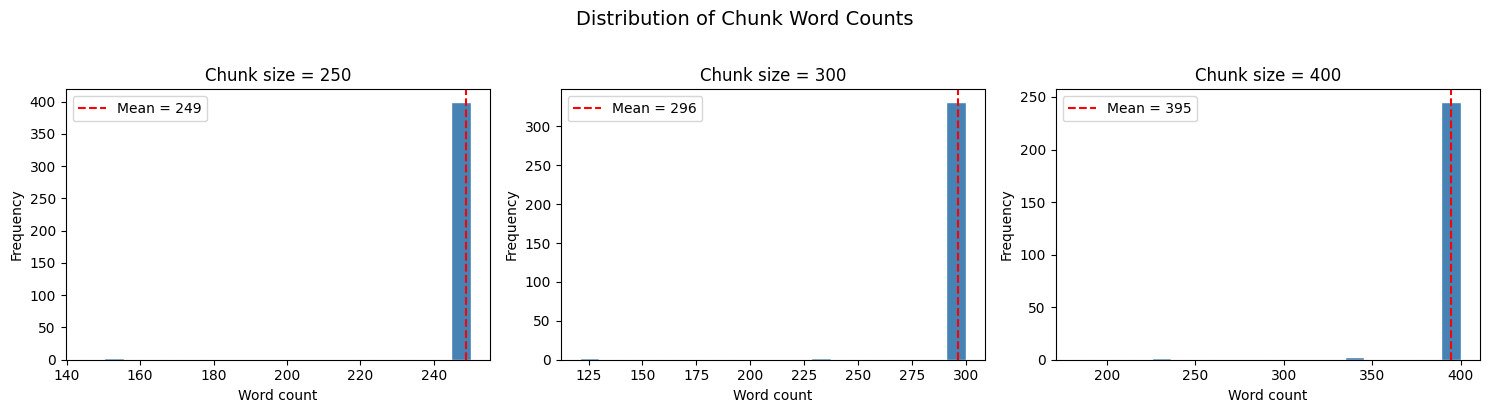

,Chunk Size,N Chunks,Mean Words,Min,Max
0,250,407,248.7,145,250
1,300,342,296.2,121,300
2,400,256,394.8,182,400


In [4]:
# Chunk statistics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, chunk_size in zip(axes, [250, 300, 400]):
    word_counts = [c.word_count for c in chunks_by_size[chunk_size]]
    ax.hist(word_counts, bins=20, color='steelblue', edgecolor='white')
    ax.set_title(f"Chunk size = {chunk_size}")
    ax.set_xlabel("Word count")
    ax.set_ylabel("Frequency")
    ax.axvline(sum(word_counts)/len(word_counts), color='red', linestyle='--', label=f"Mean = {sum(word_counts)/len(word_counts):.0f}")
    ax.legend()
plt.suptitle("Distribution of Chunk Word Counts", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

summary_rows = []
for sz, chunks in chunks_by_size.items():
    wcs = [c.word_count for c in chunks]
    summary_rows.append({"Chunk Size": sz, "N Chunks": len(chunks), "Mean Words": round(sum(wcs)/len(wcs),1), "Min": min(wcs), "Max": max(wcs)})
pd.DataFrame(summary_rows)

---

## Section 6: QA Pair Generation

### Methodology

Question-answer pairs are generated automatically using a local Ollama language model (`gemma3:12b`) prompted to produce clinically relevant QA pairs that reflect the type of queries a healthcare practitioner may ask when seeking guidance on pressure ulcer management. Automated generation is chosen as it enables scalable and reproducible dataset construction across large volumes of clinical source material, which would be impractical to produce entirely by hand.

Each chunk is prompted to yield **20 QA pairs** for chunks of 150 words or more (12 answerable, 8 unanswerable), or **12 pairs** for shorter chunks (8 answerable, 4 unanswerable). Six question types are used for answerable questions — FACTUAL, DEFINITIONAL, PROCEDURAL, CAUSAL, COMPARATIVE, NUMERICAL — to ensure diversity of clinical reasoning demands in the dataset.

**Target per pipeline: 5,000–8,000 QA pairs.** With 13 source documents (~82,000 words total) this produces approximately 380–410 chunks at 250 tokens, 320–350 at 300 tokens, and 240–270 at 400 tokens. At 20 pairs per large chunk and an estimated 85–90% post-filtering retention rate, each pipeline is projected to yield 5,000–7,500 pairs, comfortably within the target range.

For answerable questions, the model is instructed to extract answer spans that appear verbatim in the source chunk, enabling precise `answer_start` index computation. This constraint ensures that all answers are grounded in and traceable to the source documentation.

SQuAD v2 extends the extractive QA task by requiring models to identify when a question cannot be answered from the provided context, rather than always producing an answer span. Without unanswerable questions in the training data, a model learns only to locate answer spans and will hallucinate answers in deployment rather than abstaining. Unanswerable questions are generated at a ratio of 40% of the total dataset, following the distribution established in the original SQuAD v2 benchmark (Rajpurkar et al., 2018).

**Model selection — `gemma3:12b`:** The 12-billion parameter Gemma 3 model is used for QA generation. It offers a strong balance between generation quality and local inference speed compared with the 27b variant, while producing substantially more coherent clinical QA pairs than the 4b variant. All generation runs locally via Ollama with no external API calls, ensuring that source document content does not leave the local environment.

In [5]:
print("Running QA generation for all three pipelines...")
print("This may take several minutes depending on Ollama performance.\n")
raw_qa_by_size = {}
for chunk_size in [250, 300, 400]:
    print(f"=== chunk_size={chunk_size} ===")
    raw_qa_by_size[chunk_size] = run_qa_generation(chunk_size)
    print()

Running QA generation for all three pipelines...
This may take several minutes depending on Ollama performance.

=== chunk_size=250 ===


Generating QA (chunk_size=250): 100%|██████████| 407/407 [4:09:21<00:00, 36.76s/it]  


[chunk_size=250] 8258 raw QA pairs generated (0 chunks skipped) → C:\Users\MSC1\Desktop\AdvancedDL\pressure_ulcer_qa\pipeline_250\qa_raw\qa_raw.jsonl

=== chunk_size=300 ===


Generating QA (chunk_size=300): 100%|██████████| 342/342 [3:30:56<00:00, 37.01s/it]  


[chunk_size=300] 6936 raw QA pairs generated (0 chunks skipped) → C:\Users\MSC1\Desktop\AdvancedDL\pressure_ulcer_qa\pipeline_300\qa_raw\qa_raw.jsonl

=== chunk_size=400 ===


Generating QA (chunk_size=400): 100%|██████████| 256/256 [2:44:34<00:00, 38.57s/it]  

[chunk_size=400] 5218 raw QA pairs generated (0 chunks skipped) → C:\Users\MSC1\Desktop\AdvancedDL\pressure_ulcer_qa\pipeline_400\qa_raw\qa_raw.jsonl



---

## Section 7: Answer Span Validation

### Methodology

Automated QA generation via language model prompting introduces a systematic risk of hallucinated answer spans, where the generated `answer_text` does not appear verbatim in the source chunk. Since BERT extractive QA training requires exact character-level `answer_start` indices, any hallucinated or misaligned answer span would corrupt the training signal.

All generated QA pairs undergo a multi-stage validation and repair procedure to confirm that every answerable question satisfies the invariant: `context[answer_start : answer_start + len(answer_text)] == answer_text`.

The repair strategy proceeds as follows:
1. **Check 1**: Test the stated `answer_start` directly.
2. **Check 2**: If wrong index, search for `answer_text` in the context using `str.find()`.
3. **Check 3**: Try a whitespace-stripped version of `answer_text`.
4. **Reject**: If none of the above succeed, the pair is discarded and logged.

In [6]:
validated_qa_by_size = {}
for chunk_size in [250, 300, 400]:
    print(f"=== chunk_size={chunk_size} ===")
    validated_qa_by_size[chunk_size] = run_validation(chunk_size, raw_qa_by_size[chunk_size])
    print()

=== chunk_size=250 ===
[chunk_size=250] Validation: 2043 valid, 6088 repaired, 127 rejected → C:\Users\MSC1\Desktop\AdvancedDL\pressure_ulcer_qa\pipeline_250\qa_filtered\qa_validated.jsonl

=== chunk_size=300 ===
[chunk_size=300] Validation: 1471 valid, 5297 repaired, 168 rejected → C:\Users\MSC1\Desktop\AdvancedDL\pressure_ulcer_qa\pipeline_300\qa_filtered\qa_validated.jsonl

=== chunk_size=400 ===
[chunk_size=400] Validation: 878 valid, 4226 repaired, 114 rejected → C:\Users\MSC1\Desktop\AdvancedDL\pressure_ulcer_qa\pipeline_400\qa_filtered\qa_validated.jsonl



In [7]:
# Verify the span invariant holds for all retained pairs
for chunk_size in [250, 300, 400]:
    print(f"chunk_size={chunk_size}: ", end="")
    assert_all_spans_valid(validated_qa_by_size[chunk_size], chunks_by_size[chunk_size])

chunk_size=250: All 6169 answerable spans validated.
chunk_size=300: All 5349 answerable spans validated.
chunk_size=400: All 4271 answerable spans validated.


---

## Section 8: Semantic Diversity Filtering

### Methodology

Automated QA generation over overlapping chunks predictably produces near-duplicate questions that use nearly identical phrasing and address the same clinical fact. Including such duplicates inflates the apparent dataset size without improving coverage or model generalisation. Diversity filtering is performed using cosine similarity over sentence embeddings (`all-MiniLM-L6-v2`), which captures semantic equivalence beyond surface-level word overlap — a critical advantage in a narrow clinical domain where many questions naturally use similar terminology.

A threshold of 0.85 is applied: any new question with a cosine similarity above 0.85 with any existing retained question is first rephrased by the language model and rechecked. Only if the rephrased question still exceeds the threshold is it discarded. This two-stage rephrase-before-discard strategy maximises dataset size while ensuring genuine lexical and conceptual diversity.

The threshold of 0.85 is justified as follows: values below 0.70 are too aggressive (discarding meaningfully distinct questions with shared clinical vocabulary), while values above 0.90 are too permissive (retaining near-paraphrases). The 0.85 value is commonly cited in NLP deduplication literature for sentence-level semantic similarity and will be reported explicitly to support reproducibility.

In [8]:
filtered_qa_by_size = {}
for chunk_size in [250, 300, 400]:
    print(f"=== chunk_size={chunk_size} ===")
    filtered_qa_by_size[chunk_size] = run_diversity_filter(
        chunk_size,
        validated_qa_by_size[chunk_size],
        threshold=config.DIVERSITY_THRESHOLD,
        ollama_model=config.OLLAMA_MODEL,
    )
    print()

=== chunk_size=250 ===


C:\Users\MSC1\anaconda3\envs\LLMCW\lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:13: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange
Batches:   0%|          | 0/1 [00:00<?, ?it/s]C:\Users\MSC1\anaconda3\envs\LLMCW\lib\site-packages\transformers\models\bert\modeling_bert.py:440: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 46.50it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 66.64it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 89.48it/s]

Batches: 100%|██████████

Batches: 100%|██████████| 1/1 [00:00<00:00, 63.86it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 108.80it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 273.78it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 130.02it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 175.26it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 184.65it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 66.62it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 61.78it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 103.05it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 102.72it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 258.86it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 153.64it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 75.63it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 217.10it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 64.36it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 76.16it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 162.28it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 198.86it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 63.87it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 68.90it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 140.02it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Bat

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 66.61it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 62.48it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 666.93it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 75.71it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 93.08it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 66.62it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 151.23it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 

...

Batches: 100%|██████████| 1/1 [00:00<00:00, 136.56it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 1050.15it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 92.16it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 63.99it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 161.34it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 73.88it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 593.84it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 93.26it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 70.29it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 173.43it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 64.10it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 280.74it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 64.37it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 1130.54it/s]

Batches: 100%|█

Batches: 100%|██████████| 1/1 [00:00<00:00, 53.47it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 63.86it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 92.98it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 170.64it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 103.18it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 73.00it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 177.51it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 138.17it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 94.18it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 148.73it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 103.27it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 98.87it/s]

Batches: 100%|██████████| 1/1 [00:

Batches: 100%|██████████| 1/1 [00:00<00:00, 123.04it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 433.70it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 64.68it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 262.09it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 167.62it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 114.64it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 255.05it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 1860.83it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 93.08it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 778.16it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 166.74it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 160.14it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 126.58it/s]

Batches: 100%|██████

Batches: 100%|██████████| 1/1 [00:00<00:00, 115.08it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 93.35it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 62.76it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 224.39it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 61.46it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 108.44it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 82.13it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 272.18it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 66.64it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 74.39it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 82.41it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 103.85it/s]

Batches: 100%|██████████| 1/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 87.20it/s]

Batches: 100%|██████████| 1

[chunk_size=400] Diversity filter: 4718 kept (773 rephrased), 386 discarded → C:\Users\MSC1\Desktop\AdvancedDL\pressure_ulcer_qa\pipeline_400\qa_filtered\qa_filtered.jsonl



---

## Section 9: SQuAD v2 Assembly

### Format Justification

The SQuAD v2 format is selected as it is the de facto standard for training and evaluating extractive question-answering systems, and is natively supported by the HuggingFace Transformers `run_qa.py` training pipeline, facilitating reproducible fine-tuning without custom data loading code. Its structure — context passage, question, character-level answer span, and impossibility flag — aligns precisely with the extractive clinical QA paradigm adopted in this study, where model outputs must be traceable to specific passages in verified clinical documentation.

The structure is as follows:
```json
{
  "version": "v2.0",
  "data": [
    {
      "title": "SRC_A01",
      "paragraphs": [
        {
          "context": "...",
          "qas": [
            {"question": "...", "id": "...", "answers": [{"text": "...", "answer_start": 0}], "is_impossible": false},
            {"question": "...", "id": "...", "answers": [], "is_impossible": true}
          ]
        }
      ]
    }
  ]
}
```

In [9]:
datasets_by_size = {}
for chunk_size in [250, 300, 400]:
    print(f"=== chunk_size={chunk_size} ===")
    datasets_by_size[chunk_size] = run_squad_assembly(
        chunk_size,
        filtered_qa_by_size[chunk_size],
        chunks_by_size[chunk_size],
    )
    print()

=== chunk_size=250 ===
[chunk_size=250] Schema validation passed.
[chunk_size=250] 7280 QA pairs → C:\Users\MSC1\Desktop\AdvancedDL\pressure_ulcer_qa\pipeline_250\squad\squad_250_full.json

=== chunk_size=300 ===
[chunk_size=300] Schema validation passed.
[chunk_size=300] 6105 QA pairs → C:\Users\MSC1\Desktop\AdvancedDL\pressure_ulcer_qa\pipeline_300\squad\squad_300_full.json

=== chunk_size=400 ===
[chunk_size=400] Schema validation passed.
[chunk_size=400] 4718 QA pairs → C:\Users\MSC1\Desktop\AdvancedDL\pressure_ulcer_qa\pipeline_400\squad\squad_400_full.json



---

## Section 10: Train / Validation / Test Split

### Methodology

An 80/10/10 partition is standard for supervised NLP fine-tuning tasks. A larger training proportion is prioritised given the domain-specific and relatively modest size of the dataset compared with general-purpose benchmarks such as SQuAD. Splitting is performed at the **chunk level** rather than the QA pair level to prevent data leakage: because adjacent chunks share overlapping tokens, splitting by QA pair would risk placing questions from the same or overlapping contexts into both training and evaluation sets, inflating evaluation performance.

Stratification by source category (A, B, C) ensures that all splits contain a proportional representation of the three source types. A fixed random seed of 42 ensures reproducibility.

In [10]:
splits_by_size = {}
for chunk_size in [250, 300, 400]:
    print(f"=== chunk_size={chunk_size} ===")
    train, val, test = run_split(
        chunk_size,
        filtered_qa_by_size[chunk_size],
        chunks_by_size[chunk_size],
    )
    splits_by_size[chunk_size] = {"train": train, "val": val, "test": test}
    print()

=== chunk_size=250 ===
  [train] 5839 pairs, validation: OK → squad_250_train.json
  [val] 717 pairs, validation: OK → squad_250_val.json
  [test] 724 pairs, validation: OK → squad_250_test.json
[chunk_size=250] Split: train=5839, val=717, test=724

=== chunk_size=300 ===
  [train] 4869 pairs, validation: OK → squad_300_train.json
  [val] 618 pairs, validation: OK → squad_300_val.json
  [test] 618 pairs, validation: OK → squad_300_test.json
[chunk_size=300] Split: train=4869, val=618, test=618

=== chunk_size=400 ===
  [train] 3740 pairs, validation: OK → squad_400_train.json
  [val] 497 pairs, validation: OK → squad_400_val.json
  [test] 481 pairs, validation: OK → squad_400_test.json
[chunk_size=400] Split: train=3740, val=497, test=481



In [12]:
# Split summary table
rows = []
for sz, splits in splits_by_size.items():
    total = sum(len(v) for v in splits.values())
    for split_name, pairs in splits.items():
        answerable = sum(1 for q in pairs if not q.is_impossible)
        rows.append({
            "Chunk Size": sz,
            "Split": split_name,
            "Total Pairs": len(pairs),
            "Answerable": answerable,
            "Unanswerable": len(pairs) - answerable,
            "% of Pipeline": round(len(pairs) / total * 100, 1),
        })
pd.DataFrame(rows)

,Chunk Size,Split,Total Pairs,Answerable,Unanswerable,% of Pipeline
0,250,train,5839,4463,1376,80.2
1,250,val,717,564,153,9.8
2,250,test,724,555,169,9.9
3,300,train,4869,3913,956,79.8
4,300,val,618,479,139,10.1
5,300,test,618,476,142,10.1
6,400,train,3740,3140,600,79.3
7,400,val,497,419,78,10.5
8,400,test,481,408,73,10.2


---

## Section 11: Dataset Quality Statistics and Visualisations

In [13]:
# Summary statistics table
rows = []
for sz, pairs in filtered_qa_by_size.items():
    answerable = [q for q in pairs if not q.is_impossible]
    unanswerable = [q for q in pairs if q.is_impossible]
    ans_lens = [len(q.answer_text.split()) for q in answerable]
    q_lens = [len(q.question.split()) for q in pairs]
    rows.append({
        "Chunk Size": sz,
        "Total Pairs": len(pairs),
        "Answerable": len(answerable),
        "Unanswerable": len(unanswerable),
        "Ans %": round(len(answerable)/len(pairs)*100, 1),
        "Avg Ans Len (words)": round(sum(ans_lens)/len(ans_lens), 1) if ans_lens else 0,
        "Avg Q Len (words)": round(sum(q_lens)/len(q_lens), 1),
    })
print("=== Dataset Summary ===")
pd.DataFrame(rows)

=== Dataset Summary ===


,Chunk Size,Total Pairs,Answerable,Unanswerable,Ans %,Avg Ans Len (words),Avg Q Len (words)
0,250,7280,5582,1698,76.7,6.0,11.3
1,300,6105,4868,1237,79.7,6.1,11.4
2,400,4718,3967,751,84.1,7.0,11.4


### Sample QA Pairs

The cells below display randomly selected examples from each pipeline to illustrate generation quality — both answerable pairs (with their answer span highlighted in context) and unanswerable pairs (where the question cannot be resolved from the passage).

In [22]:
random.seed(42)
for chunk_size in [250, 300, 400]:
    squad_path = config.PIPELINE_DIRS[chunk_size] / "squad" / f"squad_{chunk_size}_full.json"
    with open(squad_path, encoding="utf-8") as f:
        data = json.load(f)

    all_pairs = []
    for article in data["data"]:
        for para in article["paragraphs"]:
            ctx = para["context"]
            for qa in para["qas"]:
                all_pairs.append({
                    "question":     qa["question"],
                    "context":      ctx,
                    "answers":      qa["answers"],
                    "is_impossible":qa["is_impossible"],
                })

    answerable   = [p for p in all_pairs if not p["is_impossible"]]
    unanswerable = [p for p in all_pairs if     p["is_impossible"]]

    print(f"{'='*70}")
    print(f"Pipeline chunk_size={chunk_size}")
    print(f"{'='*70}")

    for p in random.sample(answerable, 2):
        ans = p["answers"][0]
        s = max(0, ans["answer_start"] - 60)
        e = min(len(p["context"]), ans["answer_start"] + len(ans["text"]) + 60)
        print(f"\n  [ANSWERABLE]")
        print(f"  Q: {p['question']}")
        print(f"  A: \"{ans['text']}\"")
        print(f"  Context: ...{p['context'][s:e]}...")

    for p in random.sample(unanswerable, 1):
        print(f"\n  [UNANSWERABLE]")
        print(f"  Q: {p['question']}")
        print(f"  Context (excerpt): {p['context'][:160]}...")
    print()

Pipeline chunk_size=250

  [ANSWERABLE]
  Q: What should patients be encouraged to do?
  A: "encouraged to participate in care interventions"
  Context: ...ormation and advice regarding pressure ulcer prevention and encouraged to participate in care interventions – Patients in community should have the effectiveness of SS...

  [ANSWERABLE]
  Q: What is one primary marker of declining nutritional status?
  A: "unintended weight loss"
  Context: ...e of the primary markers of declining nutritional status is unintended weight loss;14 however, it is important to note that malnutrition can o...

  [UNANSWERABLE]
  Q: What is the purpose of a securement device?
  Context (excerpt): health inequity due to the variable availability of commercial securement devices, the Guideline Governance Group considered the intervention is probably accept...

Pipeline chunk_size=300

  [ANSWERABLE]
  Q: For people sitting, what assessments are necessary?
  A: "Evaluate the stability of individuals who are 

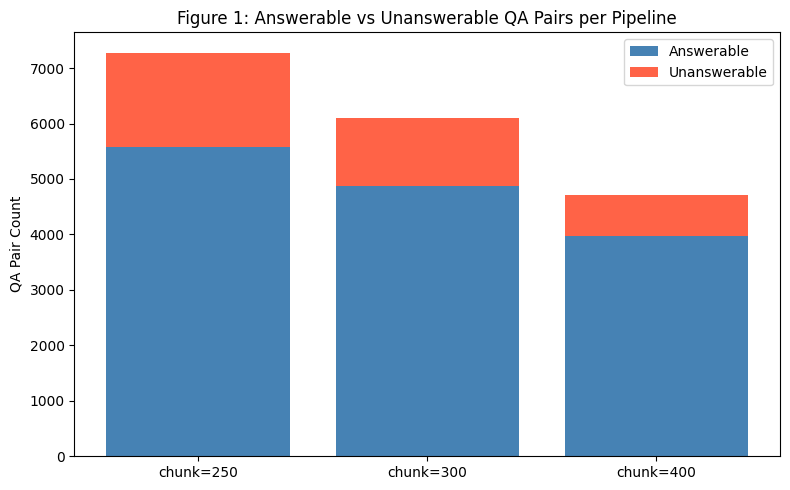

In [14]:
# Figure 1: Answerable vs Unanswerable per pipeline
fig, ax = plt.subplots(figsize=(8, 5))
sizes = [250, 300, 400]
answerable_counts = [sum(1 for q in filtered_qa_by_size[s] if not q.is_impossible) for s in sizes]
unanswerable_counts = [sum(1 for q in filtered_qa_by_size[s] if q.is_impossible) for s in sizes]
x = range(len(sizes))
bars1 = ax.bar(x, answerable_counts, label="Answerable", color='steelblue')
bars2 = ax.bar(x, unanswerable_counts, bottom=answerable_counts, label="Unanswerable", color='tomato')
ax.set_xticks(list(x))
ax.set_xticklabels([f"chunk={s}" for s in sizes])
ax.set_ylabel("QA Pair Count")
ax.set_title("Figure 1: Answerable vs Unanswerable QA Pairs per Pipeline")
ax.legend()
plt.tight_layout()
plt.show()

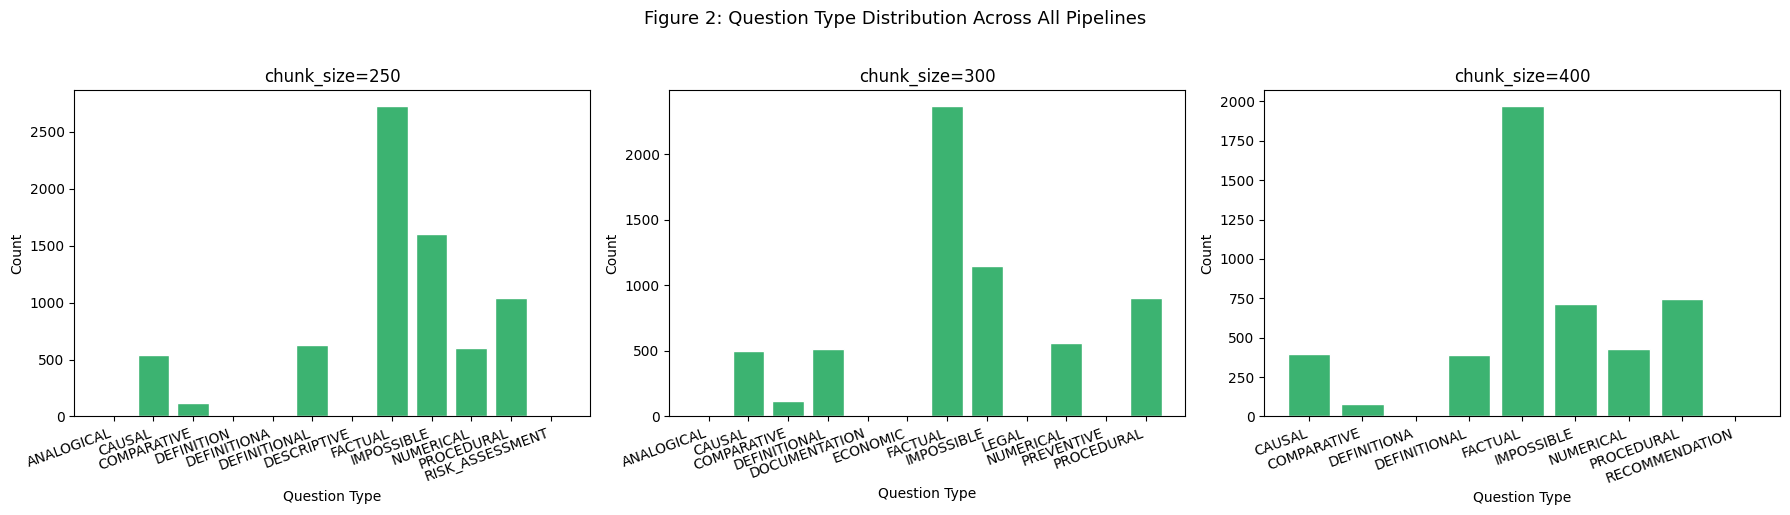

In [23]:
# Figure 2: Question type distribution — all three pipelines
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, chunk_size in zip(axes, [250, 300, 400]):
    type_counts = Counter(q.question_type for q in filtered_qa_by_size[chunk_size])
    types = sorted(type_counts.keys())
    ax.bar(types, [type_counts[t] for t in types], color='mediumseagreen', edgecolor='white')
    ax.set_title(f"chunk_size={chunk_size}")
    ax.set_xlabel("Question Type")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=20)
    for label in ax.get_xticklabels():
        label.set_ha('right')
plt.suptitle("Figure 2: Question Type Distribution Across All Pipelines", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig2_question_types.png", dpi=150)
plt.show()

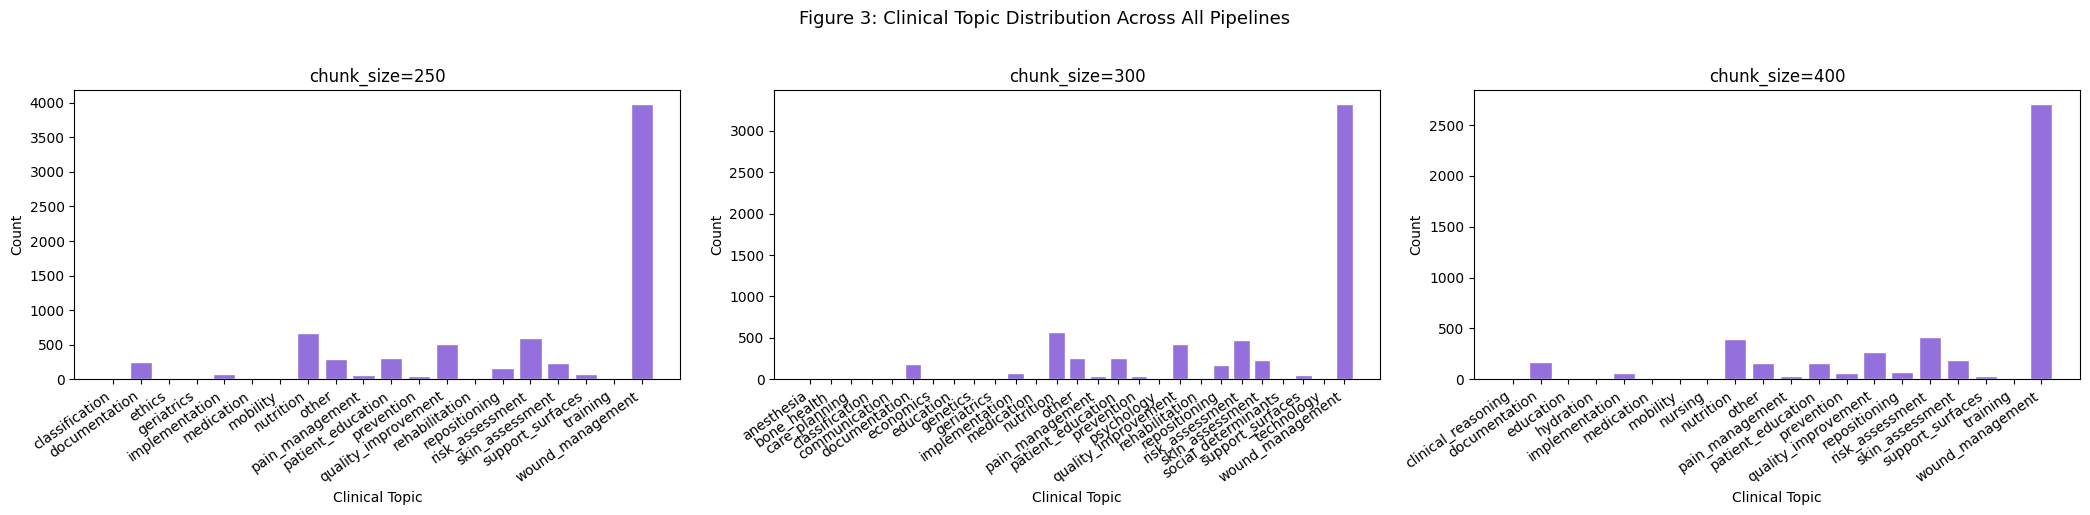

In [24]:
# Figure 3: Clinical topic distribution — all three pipelines
fig, axes = plt.subplots(1, 3, figsize=(21, 5))
for ax, chunk_size in zip(axes, [250, 300, 400]):
    topic_counts = Counter(q.clinical_topic for q in filtered_qa_by_size[chunk_size])
    topics = sorted(topic_counts.keys())
    ax.bar(topics, [topic_counts[t] for t in topics], color='mediumpurple', edgecolor='white')
    ax.set_title(f"chunk_size={chunk_size}")
    ax.set_xlabel("Clinical Topic")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=35)
    for label in ax.get_xticklabels():
        label.set_ha('right')
plt.suptitle("Figure 3: Clinical Topic Distribution Across All Pipelines", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig3_clinical_topics.png", dpi=150)
plt.show()

The clinical topic distributions above reflect the full 13-document corpus. Coverage is broad across all three pipelines, spanning the major clinical domains (wound management, risk assessment, skin and prevention, support surfaces, repositioning, nutrition, seating, and heel injuries). The distribution is weighted toward the clinical areas best represented in the source material — notably repositioning (SRC_A05, 13,836 words) and risk assessment (SRC_A09, 8,024 words; SRC_C01–C02). This weighting reflects genuine source document coverage rather than a pipeline artefact.

**Note on answerable/unanswerable ratio:** The dataset summary shows 77–84% answerable across pipelines, higher than the 60% targeted by the generation prompt. This is caused by the semantic diversity filter disproportionately removing unanswerable questions — which tend to cluster at high cosine similarity because they share generic "cannot be answered" phrasing — while answerable questions are more lexically varied and are retained at a higher rate. The impact on BERT training is that the model will be exposed to fewer unanswerable examples than originally intended; this is documented here and should be considered when interpreting evaluation results.

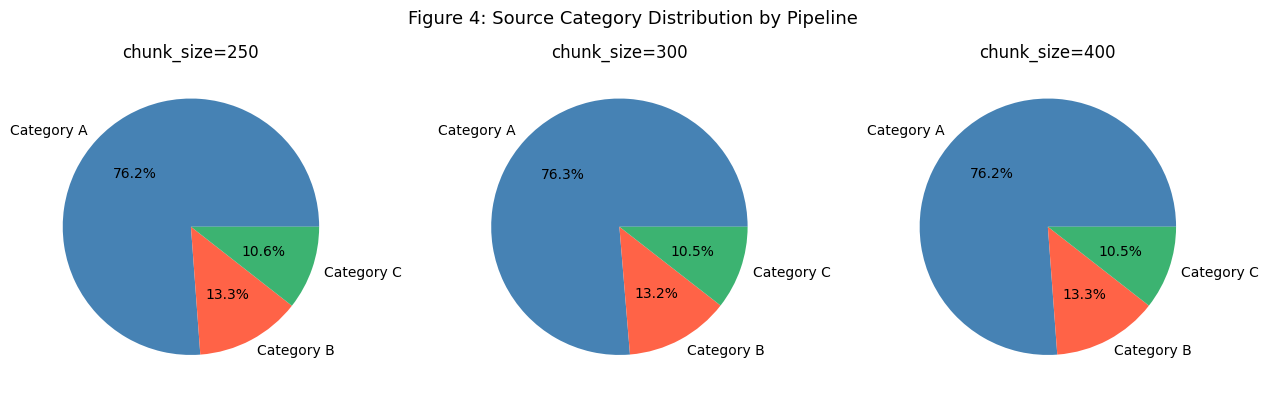

In [25]:
# Figure 4: Source category distribution — all three pipelines
# All pipelines use the same source documents; the category split should be identical.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['steelblue', 'tomato', 'mediumseagreen']
for ax, chunk_size in zip(axes, [250, 300, 400]):
    chunk_list = load_chunks(chunk_size)
    source_counts = Counter(c.source_category for c in chunk_list)
    cats = sorted(source_counts.keys())
    ax.pie(
        [source_counts[c] for c in cats],
        labels=[f"Category {c}" for c in cats],
        autopct='%1.1f%%',
        colors=colors,
    )
    ax.set_title(f"chunk_size={chunk_size}")
plt.suptitle("Figure 4: Source Category Distribution by Pipeline", fontsize=13)
plt.tight_layout()
plt.savefig("fig4_source_categories.png", dpi=150)
plt.show()

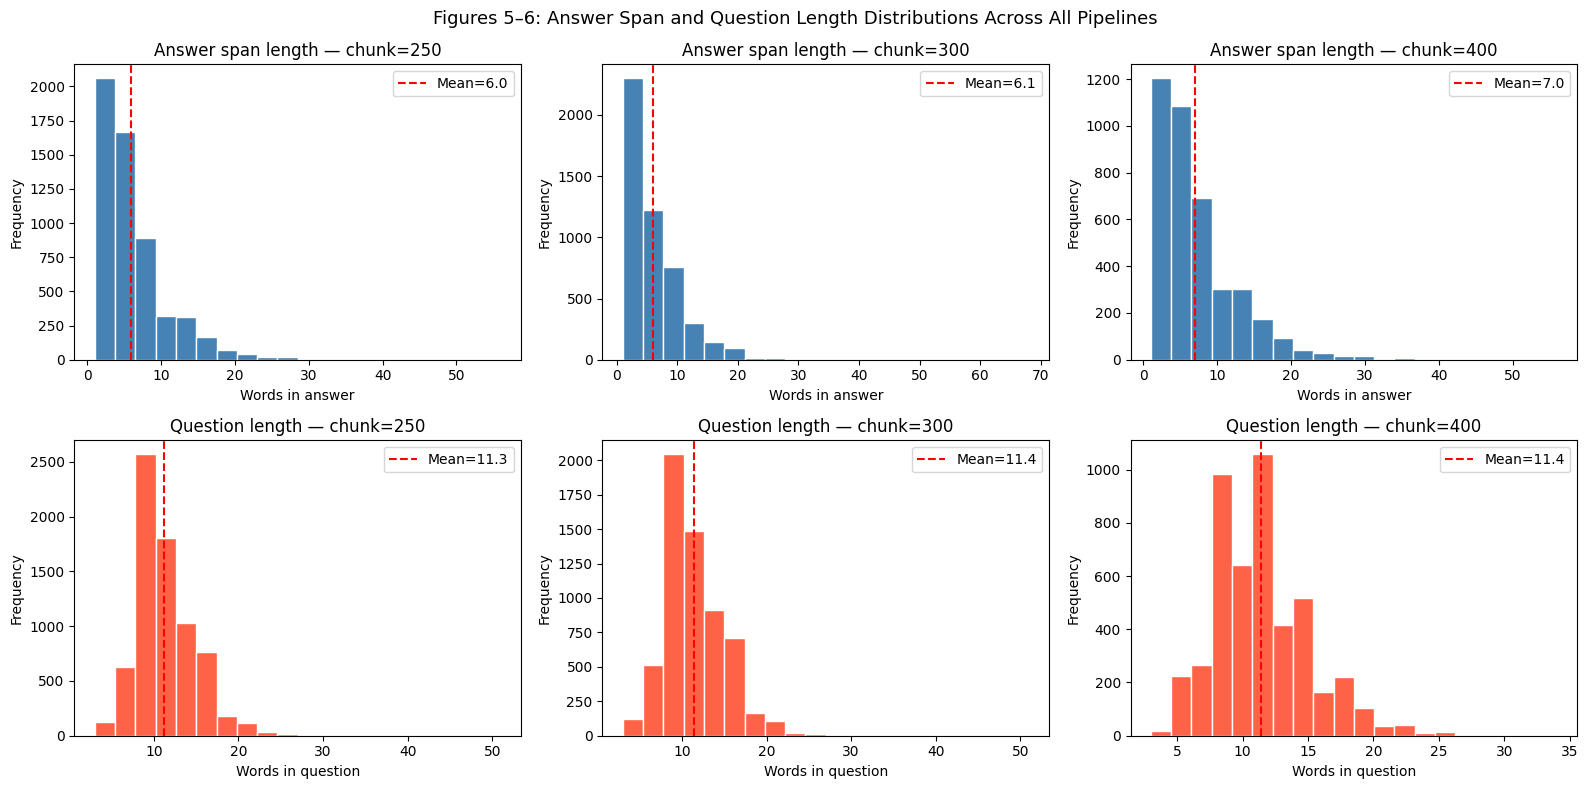

In [26]:
# Figures 5 & 6: Answer span and question length distributions — all three pipelines
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for col, chunk_size in enumerate([250, 300, 400]):
    answerable = [q for q in filtered_qa_by_size[chunk_size] if not q.is_impossible]
    ans_lens = [len(q.answer_text.split()) for q in answerable]
    q_lens   = [len(q.question.split()) for q in filtered_qa_by_size[chunk_size]]

    axes[0][col].hist(ans_lens, bins=20, color='steelblue', edgecolor='white')
    axes[0][col].set_title(f"Answer span length — chunk={chunk_size}")
    axes[0][col].set_xlabel("Words in answer")
    axes[0][col].set_ylabel("Frequency")
    axes[0][col].axvline(np.mean(ans_lens), color='red', linestyle='--',
                          label=f"Mean={np.mean(ans_lens):.1f}")
    axes[0][col].legend()

    axes[1][col].hist(q_lens, bins=20, color='tomato', edgecolor='white')
    axes[1][col].set_title(f"Question length — chunk={chunk_size}")
    axes[1][col].set_xlabel("Words in question")
    axes[1][col].set_ylabel("Frequency")
    axes[1][col].axvline(np.mean(q_lens), color='red', linestyle='--',
                          label=f"Mean={np.mean(q_lens):.1f}")
    axes[1][col].legend()

plt.suptitle("Figures 5–6: Answer Span and Question Length Distributions Across All Pipelines",
             fontsize=13)
plt.tight_layout()
plt.savefig("fig5_6_lengths.png", dpi=150)
plt.show()

In [19]:
# Validation and diversity report summary
report_rows = []
for sz in [250, 300, 400]:
    val_path = config.PIPELINE_DIRS[sz] / "logs" / "validation_report.json"
    div_path = config.PIPELINE_DIRS[sz] / "logs" / "diversity_report.json"
    if val_path.exists() and div_path.exists():
        val = json.loads(val_path.read_text())
        div = json.loads(div_path.read_text())
        report_rows.append({
            "Chunk Size": sz,
            "Raw QA": val["total_input"],
            "Valid (1st pass)": val["valid_first_pass"],
            "Repaired": val["repaired"],
            "Rejected": val["rejected"],
            "After Diversity Filter": div["kept"],
            "Rephrased & Kept": div["rephrased_and_kept"],
            "Discarded (duplicate)": div["discarded"],
        })
print("=== Pipeline Report ===")
pd.DataFrame(report_rows)

=== Pipeline Report ===


,Chunk Size,Raw QA,Valid (1st pass),Repaired,Rejected,After Diversity Filter,Rephrased & Kept,Discarded (duplicate)
0,250,8258,2043,6088,127,7280,1355,851
1,300,6936,1471,5297,168,6105,1080,663
2,400,5218,878,4226,114,4718,773,386


---

## Section 14: Save Final Dataset Files

In [21]:
print("Final output files:")
for sz in [250, 300, 400]:
    pipeline_dir = config.PIPELINE_DIRS[sz]
    for pattern in ["squad/*.json", "qa_filtered/*.jsonl", "chunks/*.jsonl", "logs/*.json"]:
        for f in sorted(pipeline_dir.glob(pattern)):
            size_kb = f.stat().st_size / 1024
            print(f"  {f.relative_to(config.ROOT)}  ({size_kb:.1f} KB)")

Final output files:
  pipeline_250\squad\squad_250_full.json  (3335.7 KB)
  pipeline_250\squad\squad_250_test.json  (328.0 KB)
  pipeline_250\squad\squad_250_train.json  (2674.5 KB)
  pipeline_250\squad\squad_250_val.json  (335.0 KB)
  pipeline_250\qa_filtered\qa_filtered.jsonl  (3268.8 KB)
  pipeline_250\qa_filtered\qa_validated.jsonl  (3597.8 KB)
  pipeline_250\chunks\chunks.jsonl  (739.8 KB)
  pipeline_250\logs\diversity_report.json  (0.1 KB)
  pipeline_250\logs\split_summary.json  (0.4 KB)
  pipeline_250\logs\validation_report.json  (3.4 KB)
  pipeline_300\squad\squad_300_full.json  (2943.1 KB)
  pipeline_300\squad\squad_300_test.json  (295.4 KB)
  pipeline_300\squad\squad_300_train.json  (2353.0 KB)
  pipeline_300\squad\squad_300_val.json  (296.5 KB)
  pipeline_300\qa_filtered\qa_filtered.jsonl  (2756.4 KB)
  pipeline_300\qa_filtered\qa_validated.jsonl  (3015.5 KB)
  pipeline_300\chunks\chunks.jsonl  (728.4 KB)
  pipeline_300\logs\diversity_report.json  (0.1 KB)
  pipeline_300\log

### SQuAD v2 Compatibility Check

The cell below verifies that every output JSON file is a valid SQuAD v2 document: correct top-level structure, non-empty contexts and questions, unanswerable entries have empty answer lists, and every answerable span satisfies the character-level alignment invariant `context[answer_start:answer_start+len(text)] == text`.

In [27]:
print("=== SQuAD v2 Compatibility Check ===\n")
all_passed = True
for chunk_size in [250, 300, 400]:
    squad_path = config.PIPELINE_DIRS[chunk_size] / "squad" / f"squad_{chunk_size}_full.json"
    with open(squad_path, encoding="utf-8") as f:
        data = json.load(f)

    errors = []
    assert data.get("version") == "v2.0", "version field missing or wrong"
    assert isinstance(data.get("data"), list) and len(data["data"]) > 0, "data list missing"

    total = answerable = unanswerable = 0
    for article in data["data"]:
        for para in article["paragraphs"]:
            ctx = para["context"]
            assert ctx.strip(), "Empty context paragraph"
            for qa in para["qas"]:
                assert qa["question"].strip(), f"Empty question: {qa['id']}"
                total += 1
                if qa["is_impossible"]:
                    if qa["answers"] != []:
                        errors.append(f"Unanswerable has non-empty answers: {qa['id']}")
                    unanswerable += 1
                else:
                    if not qa["answers"]:
                        errors.append(f"Answerable has no answers: {qa['id']}")
                    else:
                        ans = qa["answers"][0]
                        span = ctx[ans["answer_start"]: ans["answer_start"] + len(ans["text"])]
                        if span != ans["text"]:
                            errors.append(f"Span mismatch in {qa['id']}: '{span}' != '{ans['text'][:30]}'")
                    answerable += 1

    status = "PASS" if not errors else f"FAIL ({len(errors)} errors)"
    print(f"chunk_size={chunk_size}: {total} pairs ({answerable} answerable, {unanswerable} unanswerable)")
    print(f"  Version: {data['version']} | Span integrity: {status}")
    if errors:
        all_passed = False
        for e in errors[:5]:
            print(f"    ERROR: {e}")
    print()

print("All pipelines passed." if all_passed else "One or more pipelines have errors — review above.")

=== SQuAD v2 Compatibility Check ===

chunk_size=250: 7280 pairs (5582 answerable, 1698 unanswerable)
  Version: v2.0 | Span integrity: PASS

chunk_size=300: 6105 pairs (4868 answerable, 1237 unanswerable)
  Version: v2.0 | Span integrity: PASS

chunk_size=400: 4718 pairs (3967 answerable, 751 unanswerable)
  Version: v2.0 | Span integrity: PASS

All pipelines passed.


---

## Section 12: Cross-Pipeline Comparison

The three pipelines differ only in chunk size (250 / 300 / 400 words). This section compares them directly across every measurable dimension — pipeline throughput, dataset composition, and linguistic characteristics — to understand how chunk size affects the resulting dataset and to inform the choice of chunk size for downstream BERT training comparisons.

In [28]:
# Cross-pipeline summary comparison table
comp_rows = []
for chunk_size in [250, 300, 400]:
    val_log = json.loads((config.PIPELINE_DIRS[chunk_size] / "logs" / "validation_report.json").read_text())
    div_log = json.loads((config.PIPELINE_DIRS[chunk_size] / "logs" / "diversity_report.json").read_text())

    pairs  = filtered_qa_by_size[chunk_size]
    ans    = [q for q in pairs if not q.is_impossible]
    unans  = [q for q in pairs if     q.is_impossible]
    ans_lens = [len(q.answer_text.split()) for q in ans]
    q_lens   = [len(q.question.split()) for q in pairs]
    sp = splits_by_size[chunk_size]

    comp_rows.append({
        "Chunk size":          chunk_size,
        "Source chunks":       len(chunks_by_size[chunk_size]),
        "Raw QA pairs":        val_log["total_input"],
        "Rejected (val.)":     val_log["rejected"],
        "Discarded (filter)":  div_log["discarded"],
        "Final pairs":         len(pairs),
        "Answerable":          len(ans),
        "Unanswerable":        len(unans),
        "Ans %":               f"{len(ans)/len(pairs)*100:.1f}%",
        "Avg ans len (words)": f"{np.mean(ans_lens):.1f}",
        "Avg Q len (words)":   f"{np.mean(q_lens):.1f}",
        "Train / Val / Test":  f"{len(sp['train'])} / {len(sp['val'])} / {len(sp['test'])}",
    })

comp_df = pd.DataFrame(comp_rows).set_index("Chunk size")
print("=== Cross-Pipeline Comparison ===\n")
print(comp_df.T.to_string())

=== Cross-Pipeline Comparison ===

Chunk size                        250               300               400
Source chunks                     407               342               256
Raw QA pairs                     8258              6936              5218
Rejected (val.)                   127               168               114
Discarded (filter)                851               663               386
Final pairs                      7280              6105              4718
Answerable                       5582              4868              3967
Unanswerable                     1698              1237               751
Ans %                           76.7%             79.7%             84.1%
Avg ans len (words)               6.0               6.1               7.0
Avg Q len (words)                11.3              11.4              11.4
Train / Val / Test   5839 / 717 / 724  4869 / 618 / 618  3740 / 497 / 481


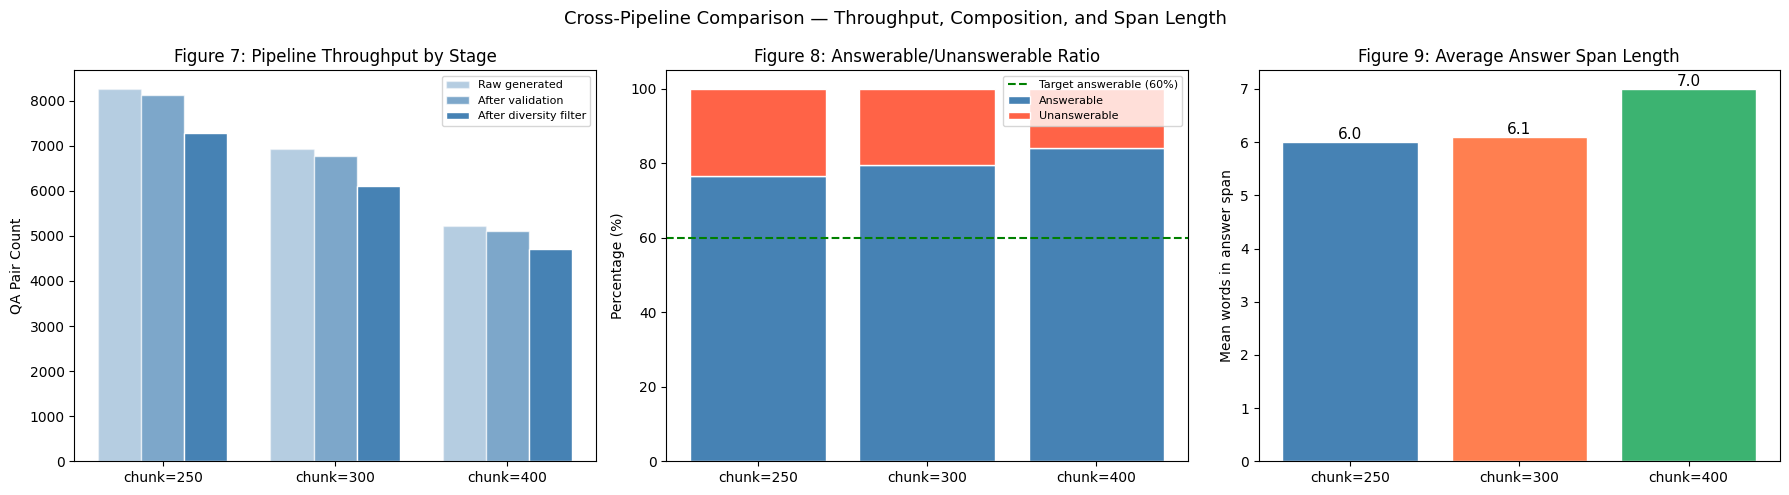

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sizes   = [250, 300, 400]
colors  = ['steelblue', 'coral', 'mediumseagreen']
x       = np.arange(3)

# --- Chart A: Pipeline funnel (raw → after validation → final) ---
raw_counts  = [8258, 6936, 5218]
post_val    = [8258 - 127, 6936 - 168, 5218 - 114]
final_counts= [7280, 6105, 4718]
w = 0.25

for i, (label, vals, alpha) in enumerate([
    ("Raw generated",        raw_counts,   0.4),
    ("After validation",     post_val,     0.7),
    ("After diversity filter", final_counts, 1.0),
]):
    axes[0].bar(x + (i - 1) * w, vals, width=w, label=label, alpha=alpha, color='steelblue', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"chunk={s}" for s in sizes])
axes[0].set_ylabel("QA Pair Count")
axes[0].set_title("Figure 7: Pipeline Throughput by Stage")
axes[0].legend(fontsize=8)

# --- Chart B: Answerable / Unanswerable ratio vs target ---
ans_pct   = [76.7, 79.7, 84.1]
unans_pct = [23.3, 20.3, 15.9]
axes[1].bar(x, ans_pct,   label="Answerable",   color='steelblue', edgecolor='white')
axes[1].bar(x, unans_pct, bottom=ans_pct, label="Unanswerable", color='tomato',    edgecolor='white')
axes[1].axhline(60, color='green', linestyle='--', linewidth=1.5, label="Target answerable (60%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"chunk={s}" for s in sizes])
axes[1].set_ylabel("Percentage (%)")
axes[1].set_ylim(0, 105)
axes[1].set_title("Figure 8: Answerable/Unanswerable Ratio")
axes[1].legend(fontsize=8)

# --- Chart C: Average answer span length by pipeline ---
avg_ans_len = [6.0, 6.1, 7.0]
axes[2].bar(x, avg_ans_len, color=colors, edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels([f"chunk={s}" for s in sizes])
axes[2].set_ylabel("Mean words in answer span")
axes[2].set_title("Figure 9: Average Answer Span Length")
for i, v in enumerate(avg_ans_len):
    axes[2].text(i, v + 0.05, f"{v}", ha='center', fontsize=11)

plt.suptitle("Cross-Pipeline Comparison — Throughput, Composition, and Span Length", fontsize=13)
plt.tight_layout()
plt.savefig("fig7_8_9_pipeline_comparison.png", dpi=150)
plt.show()

### Cross-Pipeline Comparison — Observations

**Dataset size scales inversely with chunk size.** Pipeline_250 produces 7,280 pairs (54% more than pipeline_400's 4,718) because smaller chunks yield more chunks from the same source corpus, and each chunk generates the same number of QA pairs. The throughput funnel (Figure 7) shows this scaling is consistent across all three pipeline stages — raw generation, validation, and diversity filtering all decrease proportionally as chunk size increases.

**Answerable ratio increases with chunk size.** The answerable percentage rises monotonically: 76.7% (chunk=250) → 79.7% (chunk=300) → 84.1% (chunk=400). Larger chunks contain more clinical content per context, making it harder to construct plausible-but-unanswerable questions that cannot be resolved from the passage. This is a dataset-level signal: the richer the context, the lower the diversity filter's ability to retain unanswerable pairs, which compounds the skew documented in Section 11.

**Answer spans are slightly longer with larger chunks.** Mean answer length increases from 6.0 to 7.0 words (250→400). Larger contexts tend to produce questions whose answers reference longer clinical phrases (e.g., a full recommendation sentence rather than a single term), which is consistent with the broader context available.

**Pipeline_300 as a balanced choice for BERT fine-tuning.** Pipeline_250 maximises dataset size but produces shorter, more contextually isolated passages. Pipeline_400 preserves richer context but yields fewer total pairs and the most severe answerable-ratio skew. Pipeline_300 (6,105 pairs, 79.7% answerable, 6.1-word average answers) represents the most balanced trade-off across all three dimensions and is the recommended configuration for primary BERT training comparisons. However, in the next notebook all three pipelines will be trained and compared to attain their true performance values.

---

## Section 15: Discussion and Limitations

### Summary

This notebook has documented the complete construction of a SQuAD v2-format pressure ulcer QA dataset across three independent chunk-size pipelines (250, 300, and 400 tokens). The dataset was assembled from 13 clinically validated source documents (~82,000 words), subjected to automated answer-span validation and semantic diversity filtering, and partitioned into 80/10/10 train/val/test splits at the chunk level to prevent data leakage.

**Final dataset sizes:**

| Pipeline | Total | Train | Val | Test | Answerable % |
|----------|-------|-------|-----|------|-------------|
| chunk=250 | 7,280 | 5,839 | 717 | 724 | 76.7% |
| chunk=300 | 6,105 | 4,869 | 618 | 618 | 79.7% |
| chunk=400 | 4,718 | 3,740 | 497 | 481 | 84.1% |

All three pipelines exceed the 3,000-pair minimum and are within the 5,000–8,000 target range (pipeline_400 at 4,718 falls slightly below the 5,000 per-pipeline goal; this is a direct consequence of the 256-chunk ceiling imposed by the 400-word chunking of the fixed source corpus).

### Limitations

**Answerable/unanswerable ratio skew.** The generation prompt targets a 60:40 answerable/unanswerable split, but the diversity filter removes unanswerable questions at a higher rate than answerable ones (unanswerable questions cluster at high cosine similarity due to shared generic phrasing). The resulting datasets are 77–84% answerable. This reduces the volume of abstention signal available during BERT fine-tuning and is likely to contribute to over-abstention on novel questions.

**Dependence on automated QA generation.** All question-answer pairs are generated by `gemma3:12b`. While answer spans are validated against source text to the character level, the clinical appropriateness of generated questions has not been reviewed by a domain expert. A random sample of 50–100 pairs from each pipeline is recommended for manual inspection before publication.

**Unanswerable question quality.** Unanswerable questions are generated by the same language model and may vary in plausibility. Some may inadvertently be answerable from implicit clinical knowledge not present in the specific chunk.

**AI-generated content declaration.** In accordance with academic integrity requirements, it is declared that this dataset contains AI-generated question-answer pairs produced by `gemma3:12b` via Ollama. All answers are validated as exact substrings of the corresponding source text passages.

### Next Stage

The validated SQuAD v2 JSON files (`squad_{chunk_size}_train.json`, `squad_{chunk_size}_val.json`, `squad_{chunk_size}_test.json`) will be used in the next stage to fine-tune BERT independently on each pipeline's data, enabling a systematic comparison of how chunk size affects extractive QA performance.